In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns

import dask.dataframe as dd
from pathlib import Path
import glob
import re

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from matplotlib.lines import Line2D

from statannotations.Annotator import Annotator

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")
sys.path.append("../src/tests")

In [3]:
import clustering as clstr
import bout.assembly as bt
import plot as bt_plt
import test_activity_metric_functions as test_actvt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline
from core import SITE_NAMES, FREQUENCY_COLOR_MAPPINGS

from cli import get_file_paths
import pipeline

In [4]:
def get_between_bout_intervals_in_secs(bout_metrics_group):
    raw_intervals = bout_metrics_group['start_time_of_bout'] - bout_metrics_group['end_time_of_bout'].shift(1)
    bout_metrics_group.insert(0, 'between_bout_intervals', raw_intervals)
    bout_metrics_group['ref_time'] = pd.DatetimeIndex(bout_metrics_group['start_time_of_bout'])
    bm_group_df = bout_metrics_group.set_index('ref_time')
    first_calls_per_day = bm_group_df.resample('D').first()['start_time_of_bout']
    first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)
    bm_group_df.loc[first_valid_calls_per_day, 'between_bout_intervals'] = np.NaN

    intervals = bm_group_df[~bm_group_df['between_bout_intervals'].isna()]['between_bout_intervals'].values.astype('float64')
    valid_intervals = intervals[~(np.isnan(intervals))&~(intervals==0)]
    BB_intervals_s = valid_intervals/1e9
    return BB_intervals_s

def get_valid_ipis_ms(location_sum_df):
    """
    Gets the IPIs (Inter-Pulse Intervals) for a given location and frequency group
    using the 2022_bd2_summary files stored in data.

    Ignores IPIs generated for the first call of every date since we only want to consider intervals within nights.

    Returns a numpy array of IPIs in milliseconds.
    """

    intervals = pd.to_datetime(location_sum_df['call_start_time']) - pd.to_datetime(location_sum_df['call_end_time']).shift(1)
    location_sum_df.insert(0, 'time_from_prev_call_end_time', intervals)

    location_sum_df['ref_time'] = pd.DatetimeIndex(location_sum_df['call_start_time'])
    location_sum_df = location_sum_df.set_index('ref_time')

    first_calls_per_day = location_sum_df.resample('D').first()['call_start_time']
    first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)
    location_sum_df.loc[first_valid_calls_per_day, 'time_from_prev_call_end_time'] = pd.NaT

    intervals = location_sum_df[~location_sum_df['time_from_prev_call_end_time'].isna()]['time_from_prev_call_end_time'].values.astype('float64')
    valid_intervals = intervals[~(np.isnan(intervals))&~(intervals<=0)]
    ipis_ms = valid_intervals/1e6

    return ipis_ms

In [5]:
bout_durations_groups = []
site_bout_labels = []
freq_group_bout_labels = []

bbis_in_secs_groups = []
site_bout_bbi_labels = []
freq_group_bout_bbi_labels = []

peak_frequencies_groups = []
site_call_freq_labels = []
freq_group_call_freq_labels = []

num_peak_freq_samples_per_group = []
num_bout_dur_samples_per_group = []
num_bbi_samples_per_group = []

type_for_site_key = {'Carp':'LF','Telephone':'HF'}
for site_key in ['Carp', 'Telephone']:
    freq_key = type_for_site_key[site_key]
    data_params = dict()
    data_params['site_tag'] = site_key
    data_params['type_tag'] = freq_key
    data_params['detector_tag'] = 'bd2'
    data_params['assembly_type'] = 'kmeans'
    data_params['training_set'] = 'all_locations'
    data_params['SNR_threshold'] = 3
    data_params['det_prob_threshold'] = 0.35
    data_params['recording_start'] = '00:00'
    data_params['recording_end'] = '16:00'
    data_params['cur_dc_tag'] = '30of30'
    data_params['index_time_block_in_secs'] = 5
    data_params['cycle_length'] = int(data_params['cur_dc_tag'].split('of')[-1])
    data_params['time_on'] = int(data_params['cur_dc_tag'].split('of')[0])
    data_params['time_on_in_secs'] = 60*data_params['time_on']
    file_paths = get_file_paths(data_params)

    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    if data_params['detector_tag']=='bd2':
        inds_where_dets_above_detection_probability = location_df['det_prob'].astype(float)>=data_params['det_prob_threshold']
        location_df_above_detection_probability = location_df[inds_where_dets_above_detection_probability].copy()
        inds_where_dets_above_SNR = location_df_above_detection_probability['SNR'].astype(float)>=data_params['SNR_threshold']
        location_df_above_SNR_and_detthresh = location_df_above_detection_probability[inds_where_dets_above_SNR].copy()
    else:
        location_df_above_SNR_and_detthresh = location_df.copy()
    peak_frequencies_sorted_group = location_df_above_SNR_and_detthresh["peak_frequency_WELCH"].values

    peak_frequencies_groups += [peak_frequencies_sorted_group]
    site_call_freq_labels += [SITE_NAMES[site_key].replace(" ", "\n")] * (len(peak_frequencies_sorted_group))
    freq_group_call_freq_labels += [f'{freq_key}'] * (len(peak_frequencies_sorted_group))
    num_peak_freq_samples_per_group += [len(peak_frequencies_sorted_group)]
    
    bout_params = bt.get_bout_params_from_location(location_df_above_SNR_and_detthresh, data_params)
    dc_applied_df = ss.simulate_dutycycle_on_detections(location_df_above_SNR_and_detthresh.copy(), data_params)
    bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)
    bout_metrics_group = bout_metrics[bout_metrics['freq_group']==freq_key].copy()
    bout_durations_sorted_group = bout_metrics_group["bout_duration_in_secs"].values
    bout_durations_groups += [bout_durations_sorted_group]
    site_bout_labels += [SITE_NAMES[site_key].replace(" ", "\n")] * (len(bout_durations_sorted_group))
    freq_group_bout_labels += [f'{freq_key}'] * (len(bout_durations_sorted_group))
    num_bout_dur_samples_per_group += [len(bout_durations_sorted_group)]

    bbis_s_group = get_between_bout_intervals_in_secs(bout_metrics_group)
    bbis_in_secs_groups += [bbis_s_group]
    site_bout_bbi_labels += [SITE_NAMES[site_key].replace(" ", "\n")] * (len(bbis_s_group))
    freq_group_bout_bbi_labels += [f'{freq_key}'] * (len(bbis_s_group))
    num_bbi_samples_per_group += [len(bbis_s_group)]

In [6]:
statistical_test_method = stats.mannwhitneyu
statistical_test_identifier = 'Mann-Whitney'

Carp
Pond vs. Telephone
Field: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.976e+05
Carp
Pond vs. Telephone
Field: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.599e+08
Carp
Pond vs. Telephone
Field: Mann-Whitney-Wilcoxon test two-sided, P_val:6.831e-01 U_stat=1.228e+08


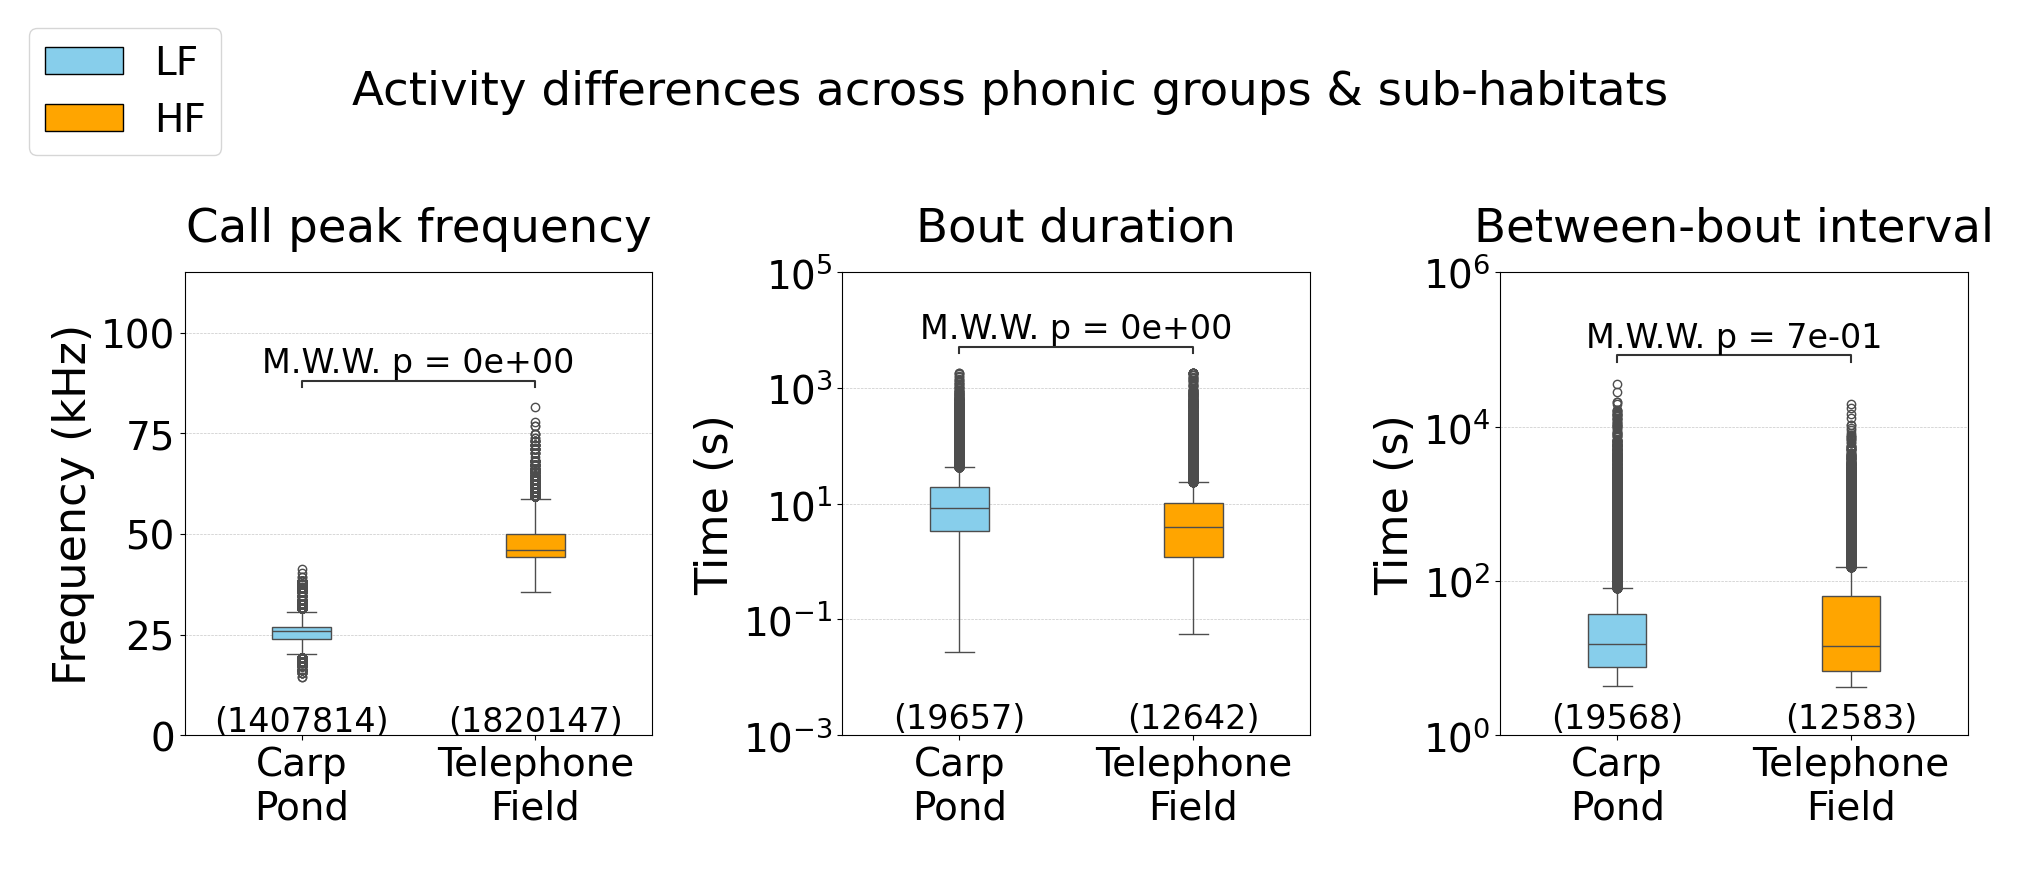

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
plt.rcParams.update({'font.size': 28})

fig.suptitle(f'Activity differences across phonic groups & sub-habitats', y=1.0)
desired_pvalue_format_string = '{:.0e}'

cur_ax = ax1
peak_freq_data = pd.DataFrame({'Peak Frequencies': np.concatenate(peak_frequencies_groups)/1e3,'Site names': site_call_freq_labels,'Groups': freq_group_call_freq_labels})
sns.boxplot(data=peak_freq_data, x='Site names', y='Peak Frequencies', hue='Groups', width=0.25, palette=FREQUENCY_COLOR_MAPPINGS, saturation=1.0, ax=cur_ax)
cur_ax.get_legend().remove()
cur_ax.set_ylabel('Frequency (kHz)', fontsize=plt.rcParams['font.size']+4)
cur_ax.tick_params(axis='y', labelsize=plt.rcParams['font.size'])
cur_ax.tick_params(axis='x', labelsize=plt.rcParams['font.size'])
cur_ax.set_xlabel('')
cur_ax.set_title('Call peak frequency', y=1.05)
cur_ax.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Add p-value annotations
annotator = Annotator(cur_ax, [('Carp\nPond', 'Telephone\nField')], data=peak_freq_data, x='Site names', y='Peak Frequencies')
annotator.configure(test=statistical_test_identifier, text_format='full', fontsize=plt.rcParams['font.size']-4)
annotator.pvalue_format._pvalue_format_string = desired_pvalue_format_string
annotator.apply_and_annotate()
cur_ax.set_ylim(0, 115)
cur_ax.set_xlim(-0.5, 1.5)
cur_ax.text(x=0, y=1, s=f'({num_peak_freq_samples_per_group[0]})', ha='center', fontsize=plt.rcParams['font.size']-4)
cur_ax.text(x=1, y=1, s=f'({num_peak_freq_samples_per_group[1]})', ha='center', fontsize=plt.rcParams['font.size']-4)

cur_ax = ax2
bout_durations_data = pd.DataFrame({'Durations': np.concatenate(bout_durations_groups), 'Site names': site_bout_labels, 'Groups': freq_group_bout_labels})
sns.boxplot(data=bout_durations_data, x='Site names', y='Durations', hue='Groups', width=0.25, palette=FREQUENCY_COLOR_MAPPINGS, saturation=1.0, ax=cur_ax)
cur_ax.get_legend().remove()
cur_ax.set_yscale('log')
cur_ax.set_ylabel('Time (s)', fontsize=plt.rcParams['font.size']+4)
cur_ax.tick_params(axis='y', labelsize=plt.rcParams['font.size'])
cur_ax.tick_params(axis='x', labelsize=plt.rcParams['font.size'])
cur_ax.set_xlabel('')
cur_ax.set_title('Bout duration', y=1.05)
cur_ax.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Add p-value annotations
annotator = Annotator(cur_ax, [('Carp\nPond', 'Telephone\nField')], data=bout_durations_data, x='Site names', y='Durations')
annotator.configure(test=statistical_test_identifier, text_format='full', fontsize=plt.rcParams['font.size']-4)
annotator.pvalue_format._pvalue_format_string = desired_pvalue_format_string
annotator.apply_and_annotate()
cur_ax.set_ylim(1e-3, 1e5)
cur_ax.set_xlim(-0.5, 1.5)
cur_ax.text(x=0, y=1e-3, s=f'({num_bout_dur_samples_per_group[0]})', ha='center', va='bottom', fontsize=plt.rcParams['font.size']-4)
cur_ax.text(x=1, y=1e-3, s=f'({num_bout_dur_samples_per_group[1]})', ha='center', va='bottom', fontsize=plt.rcParams['font.size']-4)

cur_ax = ax3
bbi_durations_data = pd.DataFrame({'BBI Durations': np.concatenate(bbis_in_secs_groups),'Site names': site_bout_bbi_labels,'Groups': freq_group_bout_bbi_labels})
sns.boxplot(data=bbi_durations_data, x='Site names', y='BBI Durations', hue='Groups', width=0.25, palette=FREQUENCY_COLOR_MAPPINGS, saturation=1.0, ax=cur_ax)
cur_ax.get_legend().remove()
cur_ax.set_yscale('log')
cur_ax.set_ylabel('Time (s)', fontsize=plt.rcParams['font.size']+4)
cur_ax.tick_params(axis='y', labelsize=plt.rcParams['font.size'])
cur_ax.tick_params(axis='x', labelsize=plt.rcParams['font.size'])
cur_ax.set_xlabel('')
cur_ax.set_title('Between-bout interval', y=1.05)
cur_ax.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Add p-value annotations
annotator = Annotator(cur_ax, [('Carp\nPond', 'Telephone\nField')], data=bbi_durations_data, x='Site names', y='BBI Durations')
annotator.configure(test=statistical_test_identifier, text_format='full', fontsize=plt.rcParams['font.size']-4)
annotator.pvalue_format._pvalue_format_string = desired_pvalue_format_string
annotator.apply_and_annotate()
cur_ax.set_ylim(1e0, 1e6)
cur_ax.set_xlim(-0.5, 1.5)
cur_ax.text(x=0, y=1, s=f'({num_bbi_samples_per_group[0]})', ha='center', va='bottom', fontsize=plt.rcParams['font.size']-4)
cur_ax.text(x=1, y=1, s=f'({num_bbi_samples_per_group[1]})', ha='center', va='bottom', fontsize=plt.rcParams['font.size']-4)

fig.tight_layout()

LF_patch = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS['LF'], edgecolor='k', label='LF')
HF_patch = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS['HF'], edgecolor='k', label='HF')
legend_patches = [LF_patch, HF_patch]

legend_ax = fig.add_axes([0, 0.0, 1.0, 1.075])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=1, loc='upper left')

fig.savefig('FIG6ABC_adityas_manuscript.png', bbox_inches='tight')
plt.show()